# Study 9: GP prior inference via Laplace + VBMC — (length_scale, mu_0, sigma)

Infer the posterior over the GP prior parameters `theta = (length_scale, mu_0, output_scale)`
that best explain the Study 9 prevalence ratings, using the Laplace marginal likelihood +
pyVBMC machinery from `model-param-recovery-vbmc-laplace.ipynb`, now factored into
[`inference.py`](inference.py) and extended with `output_scale` (sigma) as a third inferred
parameter (the recovery notebook held it fixed at 1.5).

Model recap (condition-stratified, Beta-mixture linking function):
- one GP coherence field per condition over `[x_test, x_train_cond]`; each condition heard
  generics only about its own trained region,
- epsilon-noisy RSA speaker for the trained generics (`beta=3` fixed by design),
- ratings likelihood: 2-component Beta mixture with `pz1 = sigmoid(y_test)` as the mixture
  weight; shapes are SHARED across conditions/features and FIXED during theta inference
  (kl=Beta(8,2), nkl=Beta(2,8) — see the linking-shapes note below).

Structure:
1. Load geometry + Study 9 ratings
2. Sanity check: Laplace `log Z` and the coherence mode at a reference theta
3. Objective slices along each parameter (smoothness / identifiability diagnostic)
4. 3-D VBMC over `phi = [log_ls, mu_0, log_sigma]` (saved to `results/study9-vbmc-laplace/`)
5. Posterior marginals + pairwise joints
6. Forward pass: predicted vs empirical prevalence per condition


In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")

import sys
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt

import inference as inf   # Laplace + VBMC machinery (sets jax x64; import before other jax users)

geom = inf.load_geometry()
J = geom['J']
test_feature_names, test_trait = geom['test_feature_names'], geom['test_trait']
print(f"test features: {J}")
for c in inf.CONDITIONS:
    print(f"  {c:<14}: {geom['x_train_cond'][c].shape[0]} trained features")

test features: 15
  diet          : 15 trained features
  personality   : 15 trained features
  physical      : 15 trained features
  heterogeneous : 15 trained features


## 1. Study 9 ratings, stratified by condition

0–100 slider ratings / 100; exact 0/1 responses nudged half a slider bin inward so the
Beta-density likelihood stays finite.

  diet          : 101 participants  mean rating=0.528
  personality   : 101 participants  mean rating=0.555
  physical      : 101 participants  mean rating=0.593
  heterogeneous : 99 participants  mean rating=0.543


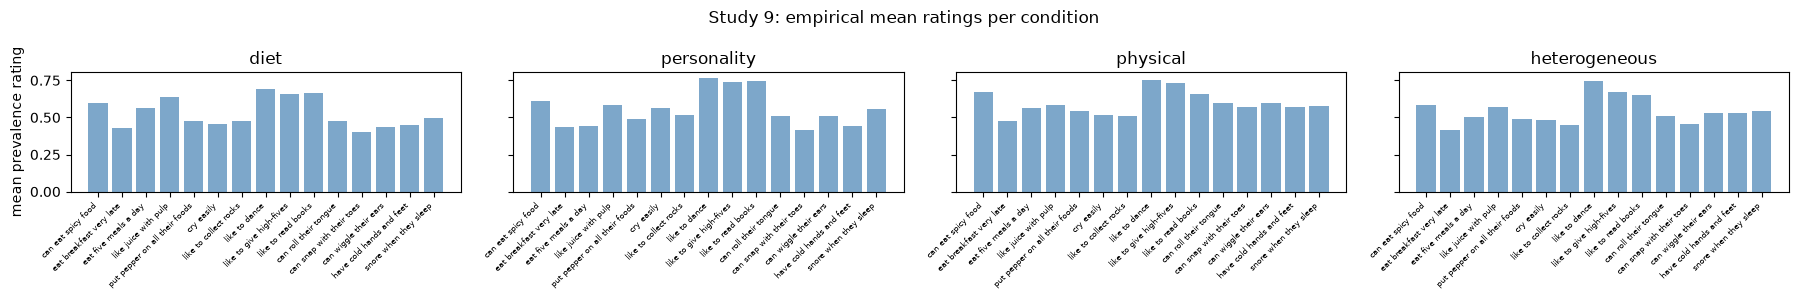

In [2]:
responses_cond, _ = inf.load_responses('../../data/study9.csv')
N_cond = {c: int(responses_cond[c].shape[0]) for c in inf.CONDITIONS}
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in inf.CONDITIONS}
for c in inf.CONDITIONS:
    print(f"  {c:<14}: {N_cond[c]} participants  mean rating={np.array(responses_cond[c]).mean():.3f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 3), sharey=True)
for ax, c in zip(axes, inf.CONDITIONS):
    ax.bar(range(J), emp_cond[c], color='steelblue', alpha=0.7)
    ax.set_xticks(range(J)); ax.set_xticklabels(test_feature_names, rotation=45, ha='right', fontsize=6)
    ax.set_title(c)
axes[0].set_ylabel('mean prevalence rating')
fig.suptitle('Study 9: empirical mean ratings per condition')
plt.tight_layout(); plt.show()

## 2. Sanity check: Laplace `log Z` at a reference theta

Linking-shapes note: unlike the parameter-recovery notebook (where the shapes were the known
truth), for real data the fixed shapes kl=Beta(8,2) / nkl=Beta(2,8) are an assumption of the
linking function, not a fitted quantity. If they misfit, that misfit is absorbed by theta —
a pre-fit of shared shapes (cf. `fit_beta_mixtures_all_features` in
`model-study9-vbmc-mcmc.ipynb`) is the natural extension; pass the result as `link_shapes=`
to `prepare_all_conditions` to rerun everything below under fitted shapes.

Here: evaluate the estimator at a reference `(ls, mu_0, sigma)` and check the Hessian is PD,
Newton converged, and the posterior-mode coherence `pz1` tracks the empirical means.

  diet          : log_Z=    -501.5  Hessian PD & converged=True  r(mode pz1, empirical mean)=+0.654
  personality   : log_Z=    -403.2  Hessian PD & converged=True  r(mode pz1, empirical mean)=+0.750
  physical      : log_Z=    -709.6  Hessian PD & converged=True  r(mode pz1, empirical mean)=+0.416


  heterogeneous : log_Z=    -527.8  Hessian PD & converged=True  r(mode pz1, empirical mean)=+0.516


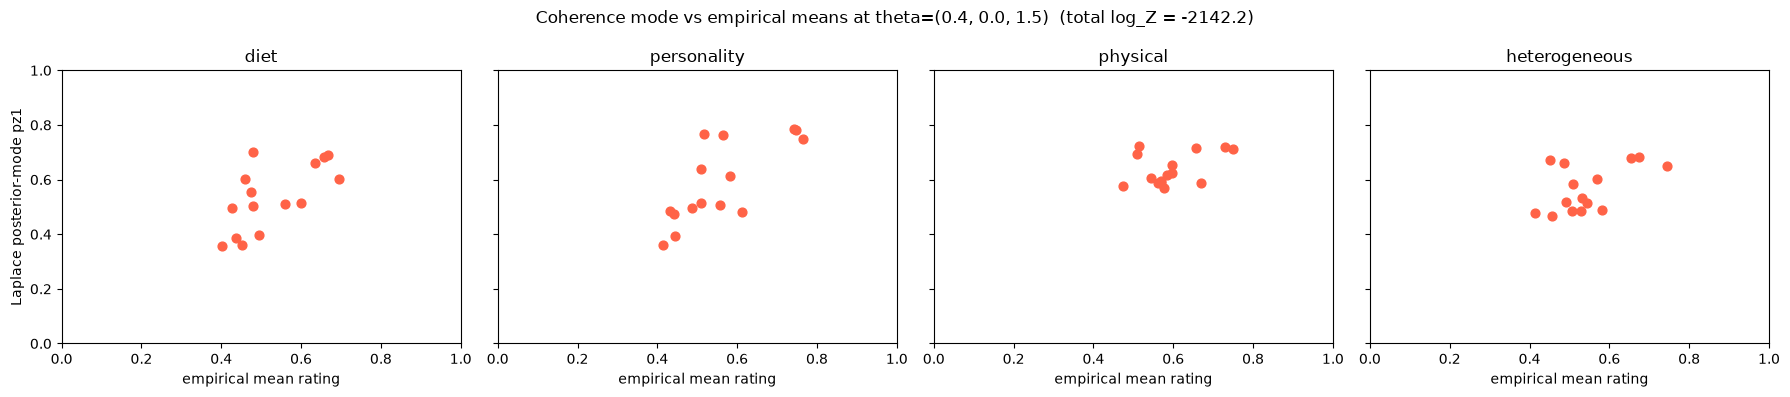

In [3]:
cond_data = inf.prepare_all_conditions(geom, responses_cond)   # link_shapes=inf.DEFAULT_LINK_SHAPES
REF_LS, REF_MU, REF_SIGMA = 0.4, 0.0, 1.5

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
total_logZ = 0.0
for ax, c in zip(axes, inf.CONDITIONS):
    logZ, y_hat, ok = inf.laplace_log_Z(cond_data[c], REF_LS, REF_MU, REF_SIGMA)
    total_logZ += logZ
    pz1_mode = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    r_emp = np.corrcoef(emp_cond[c], pz1_mode)[0, 1]
    print(f"  {c:<14}: log_Z={logZ:10.1f}  Hessian PD & converged={ok}  r(mode pz1, empirical mean)={r_emp:+.3f}")
    ax.scatter(emp_cond[c], pz1_mode, s=40, color='tomato')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('empirical mean rating'); ax.set_title(c)
axes[0].set_ylabel('Laplace posterior-mode pz1')
fig.suptitle(f'Coherence mode vs empirical means at theta=({REF_LS}, {REF_MU}, {REF_SIGMA})  (total log_Z = {total_logZ:.1f})')
plt.tight_layout(); plt.show()

## 3. Objective slices

Summed `log Z` along each parameter with the other two held at the reference. Checks the
objective is smooth and has curvature in every direction before trusting the 3-D fit.

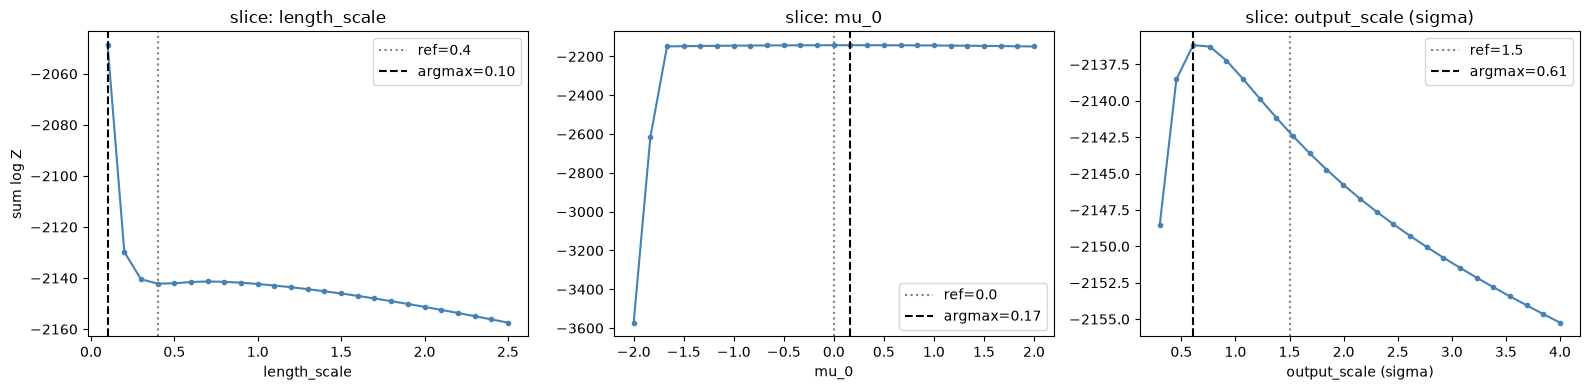

In [4]:
ls_grid    = np.linspace(0.1, 2.5, 25)
mu_grid    = np.linspace(-2.0, 2.0, 25)
sigma_grid = np.linspace(0.3, 4.0, 25)
ll_ls    = np.array([inf.total_log_lik(cond_data, ls, REF_MU, REF_SIGMA) for ls in ls_grid])
ll_mu    = np.array([inf.total_log_lik(cond_data, REF_LS, mu, REF_SIGMA) for mu in mu_grid])
ll_sigma = np.array([inf.total_log_lik(cond_data, REF_LS, REF_MU, s) for s in sigma_grid])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, grid, ll, name, ref in [(axes[0], ls_grid, ll_ls, 'length_scale', REF_LS),
                                (axes[1], mu_grid, ll_mu, 'mu_0', REF_MU),
                                (axes[2], sigma_grid, ll_sigma, 'output_scale (sigma)', REF_SIGMA)]:
    ax.plot(grid, ll, '-o', ms=3, color='steelblue')
    ax.axvline(ref, color='gray', ls=':', label=f'ref={ref}')
    ax.axvline(grid[np.argmax(ll)], color='k', ls='--', label=f'argmax={grid[np.argmax(ll)]:.2f}')
    ax.set_xlabel(name); ax.set_title(f'slice: {name}'); ax.legend()
axes[0].set_ylabel('sum log Z')
plt.tight_layout(); plt.show()

## 4. Joint 3-D VBMC over `phi = [log_ls, mu_0, log_sigma]`

Priors and box bounds live in `inference.py` (ls bounds match the recovery notebook; sigma is
lognormal-ish around the previously-fixed 1.5). The result is saved to
`results/study9-vbmc-laplace/posterior.npz` and reloaded on re-run — delete the file to refit.

In [5]:
import json

RESULTS_DIR = os.path.join('results', 'study9-vbmc-laplace')
os.makedirs(RESULTS_DIR, exist_ok=True)
POSTERIOR_PATH = os.path.join(RESULTS_DIR, 'posterior.npz')
MAX_EVALS = 300

if os.path.exists(POSTERIOR_PATH):
    z = np.load(POSTERIOR_PATH, allow_pickle=True)
    fit = {k: z[k] for k in ('ls_samples', 'mu0_samples', 'sigma_samples')}
    fit.update(json.loads(str(z['meta'])))
    print(f"loaded cached posterior from {POSTERIOR_PATH}  ({fit['convergence_status']})")
else:
    fit = inf.run_vbmc(cond_data, max_evals=MAX_EVALS)
    np.savez_compressed(
        POSTERIOR_PATH,
        ls_samples=fit['ls_samples'], mu0_samples=fit['mu0_samples'], sigma_samples=fit['sigma_samples'],
        meta=json.dumps({k: fit[k] for k in ('elbo', 'func_count', 'convergence_status', 'runtime_s')}))
    print(f"saved posterior to {POSTERIOR_PATH}")

loaded cached posterior from results\study9-vbmc-laplace\posterior.npz  (probable)


## 5. Posterior over `(length_scale, mu_0, sigma)`

convergence: probable  (evals 130, ELBO -2000.9)
  length_scale : median=0.031   95% CI [0.030, 0.036]
  mu_0         : median=0.398   95% CI [0.134, 0.677]
  sigma        : median=0.941   95% CI [0.768, 1.164]


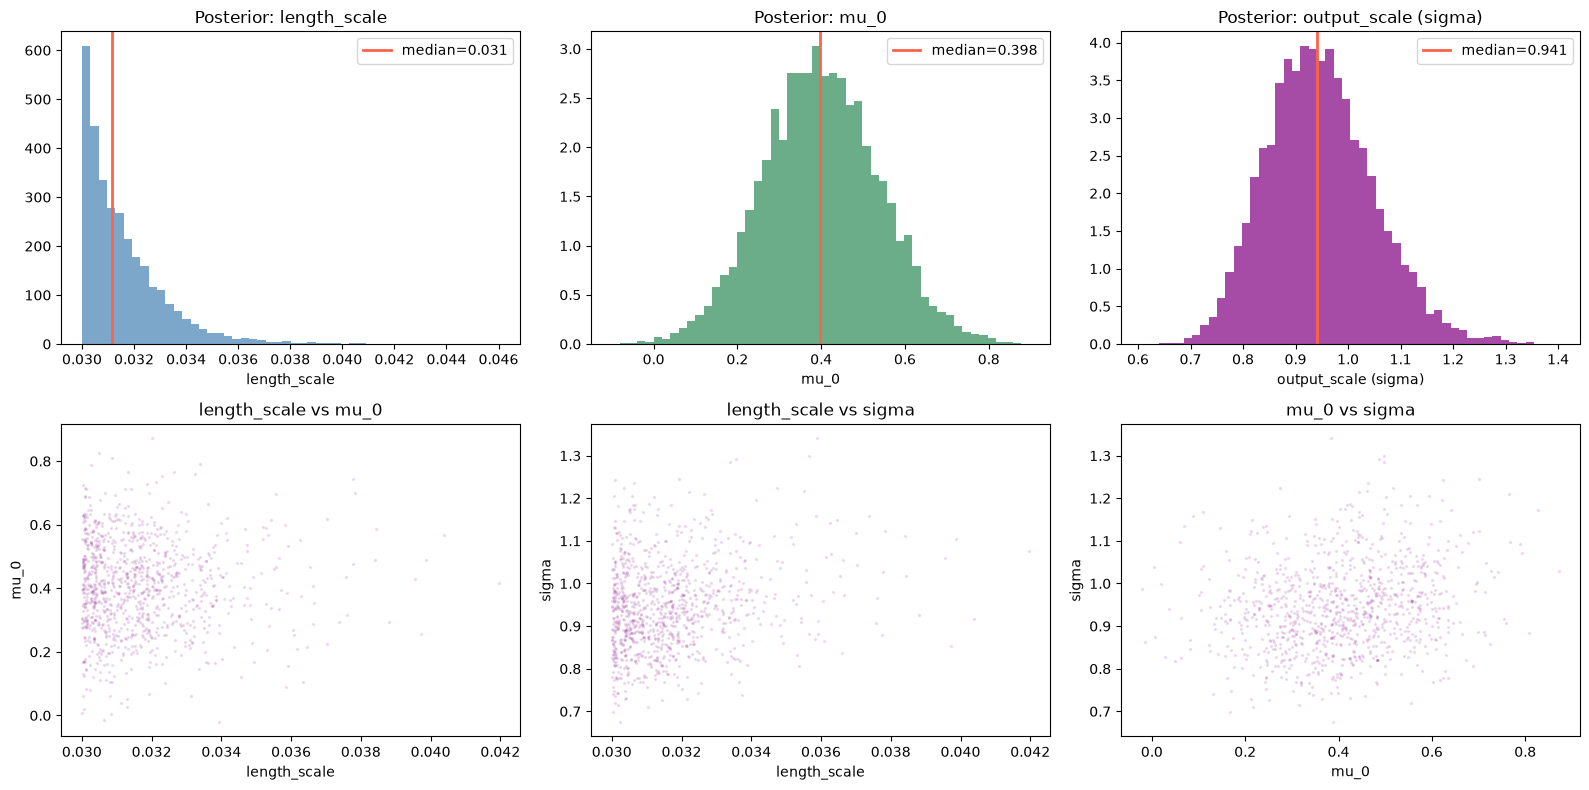

In [6]:
ls_s, mu_s, sig_s = fit['ls_samples'], fit['mu0_samples'], fit['sigma_samples']
print(f"convergence: {fit['convergence_status']}  (evals {fit['func_count']}, ELBO {fit['elbo']:.1f})")
for name, s in [('length_scale', ls_s), ('mu_0', mu_s), ('sigma', sig_s)]:
    print(f"  {name:<13}: median={np.median(s):.3f}   95% CI [{np.percentile(s,2.5):.3f}, {np.percentile(s,97.5):.3f}]")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, s, name, col in zip(axes[0], [ls_s, mu_s, sig_s],
                            ['length_scale', 'mu_0', 'output_scale (sigma)'],
                            ['steelblue', 'seagreen', 'purple']):
    ax.hist(s, bins=50, density=True, color=col, alpha=0.7)
    ax.axvline(np.median(s), color='tomato', lw=2, label=f'median={np.median(s):.3f}')
    ax.set_xlabel(name); ax.set_title(f'Posterior: {name}'); ax.legend()
for ax, (xs, ys, xn, yn) in zip(axes[1], [(ls_s, mu_s, 'length_scale', 'mu_0'),
                                          (ls_s, sig_s, 'length_scale', 'sigma'),
                                          (mu_s, sig_s, 'mu_0', 'sigma')]):
    ax.scatter(xs[::10], ys[::10], alpha=0.1, s=2, color='purple')
    ax.set_xlabel(xn); ax.set_ylabel(yn); ax.set_title(f'{xn} vs {yn}')
plt.tight_layout(); plt.show()

## 6. Forward pass: predicted vs empirical prevalence per condition

At the posterior median theta: Laplace posterior-mode coherence `pz1` per condition, then
`E[rating] = pz1*mean_kl + (1-pz1)*mean_nkl` under the fixed linking shapes. The
condition x trait heatmaps show whether training a region raises its matched-trait test
features (the diagonal), in both prediction and data.

Forward pass at posterior median: ls=0.031, mu_0=0.398, sigma=0.941


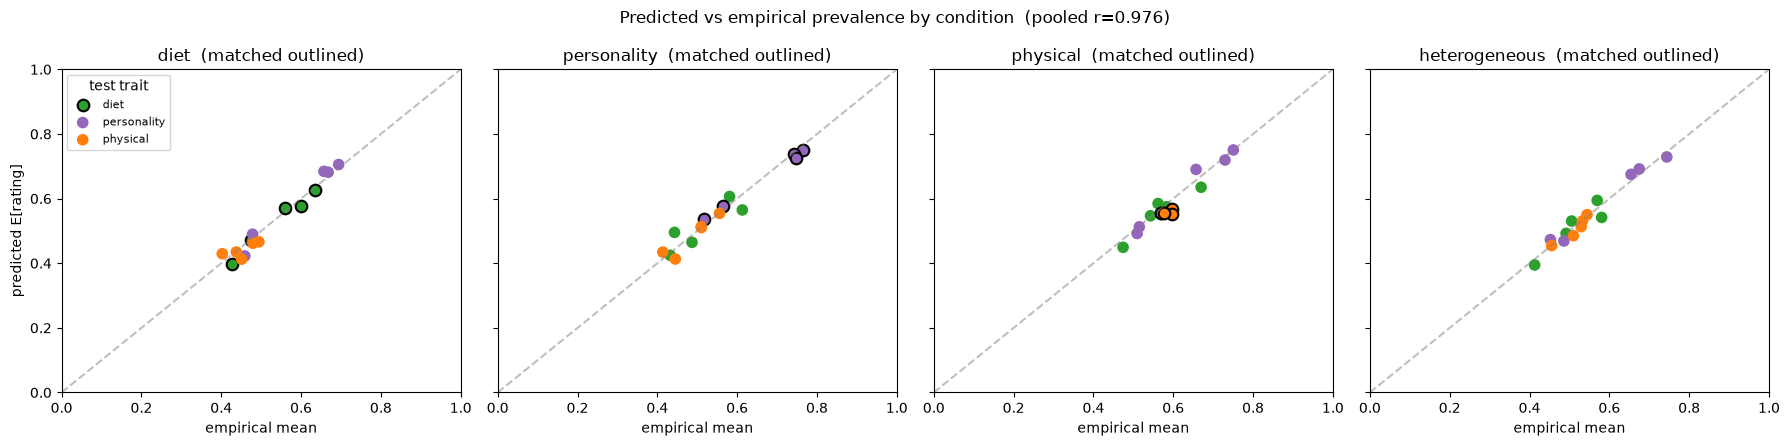

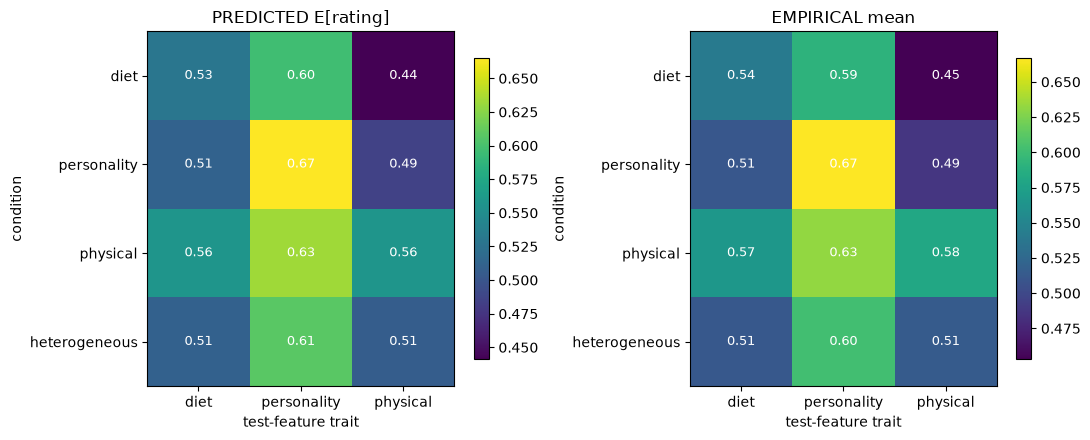

In [7]:
ls_m, mu_m, sig_m = float(np.median(ls_s)), float(np.median(mu_s)), float(np.median(sig_s))
print(f"Forward pass at posterior median: ls={ls_m:.3f}, mu_0={mu_m:.3f}, sigma={sig_m:.3f}")

a_kl, b_kl, a_nkl, b_nkl = inf.DEFAULT_LINK_SHAPES
mean_kl, mean_nkl = a_kl/(a_kl+b_kl), a_nkl/(a_nkl+b_nkl)

pz1_mode_cond, pred_cond = {}, {}
for c in inf.CONDITIONS:
    _, y_hat, ok = inf.laplace_log_Z(cond_data[c], ls_m, mu_m, sig_m)
    pz1_mode_cond[c] = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    pred_cond[c] = pz1_mode_cond[c]*mean_kl + (1-pz1_mode_cond[c])*mean_nkl
    if not ok:
        print(f"  warning: {c} Laplace mode not cleanly converged")

traits = np.array(test_trait)
tcolor = {'diet': 'tab:green', 'personality': 'tab:purple', 'physical': 'tab:orange'}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True, sharey=True)
for ax, c in zip(axes, inf.CONDITIONS):
    for tr in tcolor:
        m = traits == tr
        ax.scatter(emp_cond[c][m], pred_cond[c][m], s=70, color=tcolor[tr],
                   edgecolor=('k' if tr == c else 'none'), linewidth=1.5, label=tr)
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{c}  (matched outlined)"); ax.set_xlabel('empirical mean')
axes[0].set_ylabel("predicted E[rating]"); axes[0].legend(fontsize=8, title='test trait')
r_all = np.corrcoef(np.concatenate([emp_cond[c] for c in inf.CONDITIONS]),
                    np.concatenate([pred_cond[c] for c in inf.CONDITIONS]))[0, 1]
fig.suptitle(f'Predicted vs empirical prevalence by condition  (pooled r={r_all:.3f})')
plt.tight_layout(); plt.show()

def by_trait(d):
    return np.array([[d[c][traits == tr].mean() for tr in ['diet', 'personality', 'physical']]
                     for c in inf.CONDITIONS])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, ttl in [(axes[0], by_trait(pred_cond), 'PREDICTED E[rating]'),
                     (axes[1], by_trait(emp_cond), 'EMPIRICAL mean')]:
    im = ax.imshow(mat, aspect='auto', cmap='viridis')
    ax.set_xticks(range(3)); ax.set_xticklabels(['diet', 'personality', 'physical'])
    ax.set_yticks(range(4)); ax.set_yticklabels(inf.CONDITIONS)
    ax.set_xlabel('test-feature trait'); ax.set_ylabel('condition'); ax.set_title(ttl)
    for (i, j), v in np.ndenumerate(mat):
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='w', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()

## 7. Inferring the linking shapes (profiled, per feature)

Everything above FIXED the linking shapes at kl=Beta(8,2)/nkl=Beta(2,8). Here they are inferred
instead, using the machinery from the MCMC notebooks (`fit_beta_mixtures_all_features`): at every
theta evaluation, per-feature shapes — SHARED across conditions — are re-fit to all participants,
each weighted by their own condition's coherence `pz1`. As in the MCMC pipeline, `pz1` comes from
the RATINGS-FREE coherence mode (GP prior + training utterances only; the test ratings never
inform the coherences), so the fit is one-shot per eval and depends on nothing but theta.

Caveats, stated once:
- This is a PROFILE likelihood over the shapes (empirical-Bayes style), not a marginalization —
  the shape-fit uncertainty is not propagated into the theta posterior.
- The shapes are fit by the bounded INTERVAL likelihood but `log Z` scores the Beta DENSITY;
  fitted shapes are clipped to `inference.SHAPE_CLIP` to keep near-delta components off the
  density's pathological regime.
- Identifiability logic (from the MCMC notebooks): per-feature shapes absorb each feature's
  baseline prevalence, so theta is identified by the CROSS-CONDITION contrast, which
  condition-invariant shapes cannot absorb.

First, slices of the profiled objective (same diagnostic as section 3 — note whether
`length_scale` now has an interior optimum instead of piling onto the lower bound).

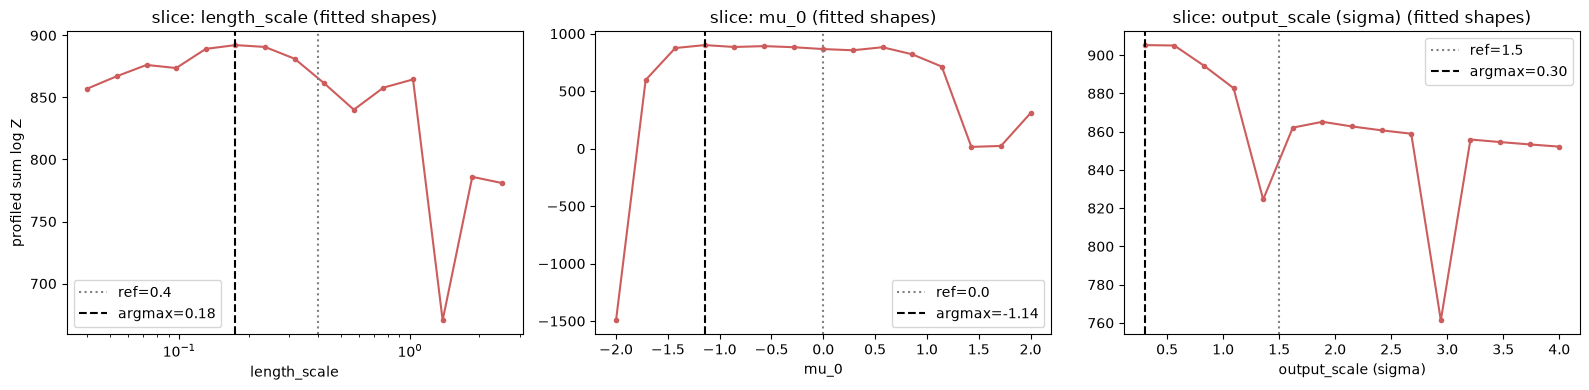

In [8]:
ls_grid_f    = np.geomspace(0.04, 2.5, 15)
mu_grid_f    = np.linspace(-2.0, 2.0, 15)
sigma_grid_f = np.linspace(0.3, 4.0, 15)
ll_ls_f    = np.array([inf.total_log_lik_free_shapes(geom, responses_cond, ls, REF_MU, REF_SIGMA) for ls in ls_grid_f])
ll_mu_f    = np.array([inf.total_log_lik_free_shapes(geom, responses_cond, REF_LS, mu, REF_SIGMA) for mu in mu_grid_f])
ll_sigma_f = np.array([inf.total_log_lik_free_shapes(geom, responses_cond, REF_LS, REF_MU, s) for s in sigma_grid_f])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, grid, ll, name, ref in [(axes[0], ls_grid_f, ll_ls_f, 'length_scale', REF_LS),
                                (axes[1], mu_grid_f, ll_mu_f, 'mu_0', REF_MU),
                                (axes[2], sigma_grid_f, ll_sigma_f, 'output_scale (sigma)', REF_SIGMA)]:
    ax.plot(grid, ll, '-o', ms=3, color='indianred')
    ax.axvline(ref, color='gray', ls=':', label=f'ref={ref}')
    ax.axvline(grid[np.argmax(ll)], color='k', ls='--', label=f'argmax={grid[np.argmax(ll)]:.2f}')
    ax.set_xlabel(name); ax.set_title(f'slice: {name} (fitted shapes)'); ax.legend()
axes[0].set_xscale('log')
axes[0].set_ylabel('profiled sum log Z')
plt.tight_layout(); plt.show()

### 7a. VBMC with fitted shapes

Same 3-D phi box and priors as section 4; only the objective changes. Cached to
`results/study9-vbmc-laplace/posterior-fitted-shapes.npz` — delete to refit.

In [9]:
POSTERIOR_FITTED_PATH = os.path.join(RESULTS_DIR, 'posterior-fitted-shapes.npz')

if os.path.exists(POSTERIOR_FITTED_PATH):
    z = np.load(POSTERIOR_FITTED_PATH, allow_pickle=True)
    fit_f = {k: z[k] for k in ('ls_samples', 'mu0_samples', 'sigma_samples')}
    fit_f.update(json.loads(str(z['meta'])))
    print(f"loaded cached posterior from {POSTERIOR_FITTED_PATH}  ({fit_f['convergence_status']})")
else:
    fit_f = inf.run_vbmc_free_shapes(geom, responses_cond, max_evals=MAX_EVALS)
    np.savez_compressed(
        POSTERIOR_FITTED_PATH,
        ls_samples=fit_f['ls_samples'], mu0_samples=fit_f['mu0_samples'], sigma_samples=fit_f['sigma_samples'],
        meta=json.dumps({k: fit_f[k] for k in ('elbo', 'func_count', 'convergence_status', 'runtime_s')}))
    print(f"saved posterior to {POSTERIOR_FITTED_PATH}")

Reshaping x0 to row vector.


Reshaping lower bounds to (1, 3).


Reshaping upper bounds to (1, 3).


Reshaping plausible lower bounds to (1, 3).


Reshaping plausible upper bounds to (1, 3).


...

    52        265         903.22         0.14         0.00       23      0.232     stable


   inf        265         903.29         0.13         0.00       50      0.232     finalize


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: 903.290 +/-0.135.


saved posterior to results\study9-vbmc-laplace\posterior-fitted-shapes.npz


### 7b. Posterior: fitted shapes vs fixed shapes

convergence: probable  (evals 265, ELBO 903.3)
param                         fixed shapes               fitted shapes
length_scale          0.031 [0.030, 0.036]        0.264 [0.197, 0.346]
mu_0                  0.398 [0.134, 0.677]      -0.014 [-0.156, 0.151]
sigma                 0.941 [0.768, 1.164]        0.570 [0.430, 0.733]


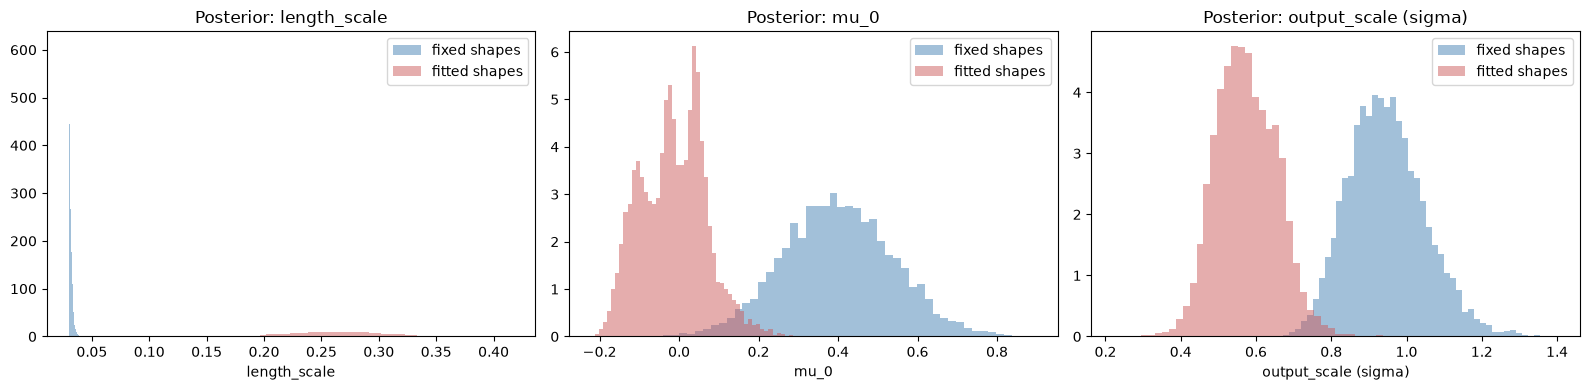

In [10]:
print(f"convergence: {fit_f['convergence_status']}  (evals {fit_f['func_count']}, ELBO {fit_f['elbo']:.1f})")
print(f"{'param':<14}{'fixed shapes':>28}{'fitted shapes':>28}")
for name, s_fix, s_fit in [('length_scale', ls_s, fit_f['ls_samples']),
                           ('mu_0', mu_s, fit_f['mu0_samples']),
                           ('sigma', sig_s, fit_f['sigma_samples'])]:
    def fmt(s): return f"{np.median(s):7.3f} [{np.percentile(s,2.5):.3f}, {np.percentile(s,97.5):.3f}]"
    print(f"{name:<14}{fmt(s_fix):>28}{fmt(s_fit):>28}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, s_fix, s_fit, name in zip(axes,
                                  [ls_s, mu_s, sig_s],
                                  [fit_f['ls_samples'], fit_f['mu0_samples'], fit_f['sigma_samples']],
                                  ['length_scale', 'mu_0', 'output_scale (sigma)']):
    ax.hist(s_fix, bins=50, density=True, color='steelblue', alpha=0.5, label='fixed shapes')
    ax.hist(s_fit, bins=50, density=True, color='indianred', alpha=0.5, label='fitted shapes')
    ax.set_xlabel(name); ax.set_title(f'Posterior: {name}'); ax.legend()
plt.tight_layout(); plt.show()

### 7c. Fitted shapes at the posterior median + forward pass

The fitted per-feature component means show what the linking function absorbed (each feature's
baseline prevalence). Forward pass as in section 6, now under the fitted shapes.

Posterior median (fitted shapes): ls=0.264, mu_0=-0.014, sigma=0.570


saved fitted shapes to results\study9-vbmc-laplace\fitted-link-shapes.csv (+ .npz with theta)


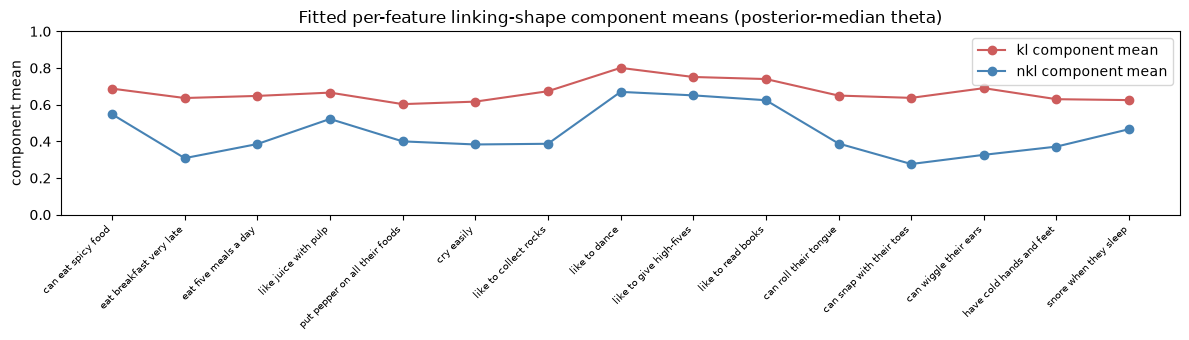

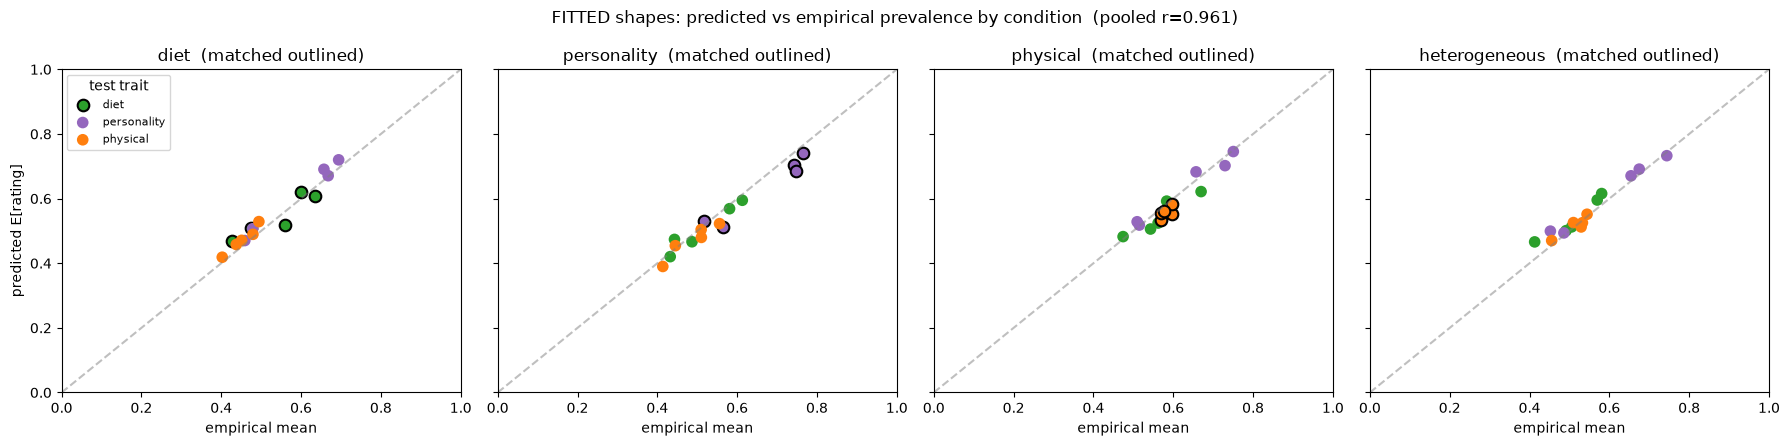

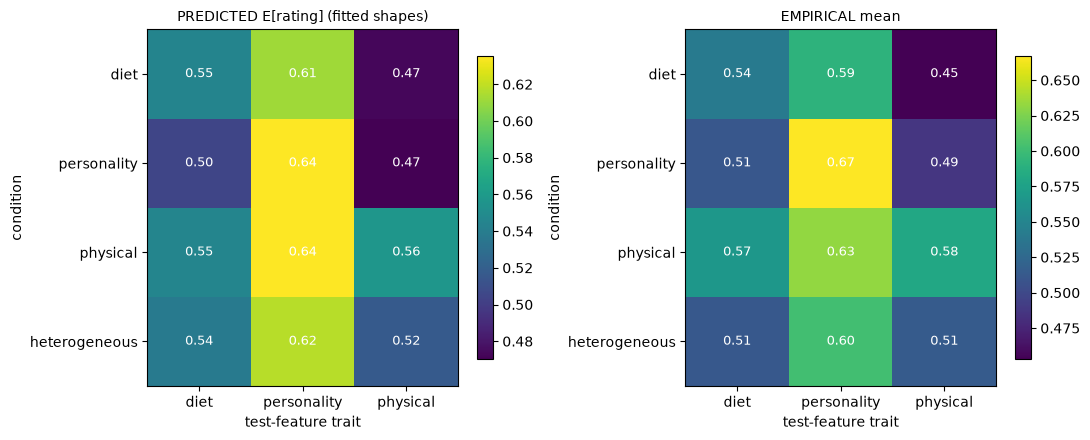

In [11]:
ls_f, mu_f, sig_f = (float(np.median(fit_f['ls_samples'])), float(np.median(fit_f['mu0_samples'])),
                     float(np.median(fit_f['sigma_samples'])))
print(f"Posterior median (fitted shapes): ls={ls_f:.3f}, mu_0={mu_f:.3f}, sigma={sig_f:.3f}")

_, shapes_f, cond_data_f = inf.total_log_lik_free_shapes(
    geom, responses_cond, ls_f, mu_f, sig_f, return_shapes=True)
mean_kl_f  = shapes_f[:, 0] / (shapes_f[:, 0] + shapes_f[:, 1])
mean_nkl_f = shapes_f[:, 2] / (shapes_f[:, 2] + shapes_f[:, 3])

# persist the fitted per-feature shapes for comparison with other beta-fitting methods
SHAPES_CSV = os.path.join(RESULTS_DIR, 'fitted-link-shapes.csv')
np.savez_compressed(os.path.join(RESULTS_DIR, 'fitted-link-shapes.npz'),
                    shapes=shapes_f, feature_names=np.array(test_feature_names),
                    theta=np.array([ls_f, mu_f, sig_f]))
import csv as _csv
with open(SHAPES_CSV, 'w', newline='') as f:
    w = _csv.writer(f)
    w.writerow(['feature', 'trait', 'a_kl', 'b_kl', 'a_nkl', 'b_nkl', 'mean_kl', 'mean_nkl'])
    for j, name in enumerate(test_feature_names):
        w.writerow([name, test_trait[j], *[f'{v:.4f}' for v in shapes_f[j]],
                    f'{mean_kl_f[j]:.4f}', f'{mean_nkl_f[j]:.4f}'])
print(f'saved fitted shapes to {SHAPES_CSV} (+ .npz with theta)')


fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(range(J), mean_kl_f, 'o-', color='indianred', label='kl component mean')
ax.plot(range(J), mean_nkl_f, 'o-', color='steelblue', label='nkl component mean')
ax.set_xticks(range(J)); ax.set_xticklabels(test_feature_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('component mean'); ax.set_ylim(0, 1); ax.legend()
ax.set_title('Fitted per-feature linking-shape component means (posterior-median theta)')
plt.tight_layout(); plt.show()

pz1_mode_f, pred_cond_f = {}, {}
for c in inf.CONDITIONS:
    _, y_hat, ok = inf.laplace_log_Z(cond_data_f[c], ls_f, mu_f, sig_f)
    pz1_mode_f[c] = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    pred_cond_f[c] = pz1_mode_f[c]*mean_kl_f + (1-pz1_mode_f[c])*mean_nkl_f
    if not ok:
        print(f"  warning: {c} Laplace mode not cleanly converged")

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True, sharey=True)
for ax, c in zip(axes, inf.CONDITIONS):
    for tr in tcolor:
        m = traits == tr
        ax.scatter(emp_cond[c][m], pred_cond_f[c][m], s=70, color=tcolor[tr],
                   edgecolor=('k' if tr == c else 'none'), linewidth=1.5, label=tr)
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{c}  (matched outlined)"); ax.set_xlabel('empirical mean')
axes[0].set_ylabel("predicted E[rating]"); axes[0].legend(fontsize=8, title='test trait')
r_all_f = np.corrcoef(np.concatenate([emp_cond[c] for c in inf.CONDITIONS]),
                      np.concatenate([pred_cond_f[c] for c in inf.CONDITIONS]))[0, 1]
fig.suptitle(f'FITTED shapes: predicted vs empirical prevalence by condition  (pooled r={r_all_f:.3f})')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, ttl in [(axes[0], by_trait(pred_cond_f), 'PREDICTED E[rating] (fitted shapes)'),
                     (axes[1], by_trait(emp_cond), 'EMPIRICAL mean')]:
    im = ax.imshow(mat, aspect='auto', cmap='viridis')
    ax.set_xticks(range(3)); ax.set_xticklabels(['diet', 'personality', 'physical'])
    ax.set_yticks(range(4)); ax.set_yticklabels(inf.CONDITIONS)
    ax.set_xlabel('test-feature trait'); ax.set_ylabel('condition'); ax.set_title(ttl, fontsize=10)
    for (i, j), v in np.ndenumerate(mat):
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='w', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()